<a href="https://colab.research.google.com/github/Kashishkewat/AI-and-ML/blob/main/rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense,SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math

In [30]:
def get_train_test(url,split_percent=0.8):

 df=pd.read_csv(url,usecols=[1],engine='python')
 data=np.array(df.values.astype("float32"))
 scaler=MinMaxScaler(feature_range=(0,1))
 data=scaler.fit_transform(data).flatten()
 n=len(data)
 split=int(n*split_percent)
 train_data=data[range(split)]
 test_data=data[split:]
 return train_data,test_data,data

In [14]:
def get_XY(dat,time_steps):
  Y_ind=np.arange(time_steps,len(dat),time_steps)
  Y =dat[Y_ind]
  rows_X=len(Y)
  X=dat[range(time_steps*rows_X)]
  X=np.reshape(X,(rows_X,time_steps,1))
  return X,Y

In [44]:
def create_RNN(hidden_units,input_shape,activation,dense_units):
  model=Sequential()
  model.add(SimpleRNN(hidden_units,input_shape=input_shape,activation=activation[0]))
  model.add(Dense(units=dense_units,activation=activation[1]))
  model.compile(optimizer='adam',loss='mse',metrics=['accuracy'])
  return model

In [45]:
def print_error(trainY,testY,train_predict,test_predict):
  trainScore=math.sqrt(mean_squared_error(trainY,train_predict))
  test_rmse=math.sqrt(mean_squared_error(testY,test_predict))
  print('Train Score: %.2f RMSE' % (trainScore))
  print('Test Score: %.2f RMSE' % (test_rmse))
#

In [59]:
def plot_result(trainY,testY,train_predict,test_predict):
  actual=np.append(trainY,testY)
  predictions=np.append(train_predict,test_predict)
  rows=len(trainY)
  plt.figure(figsize=(15,6),dpi=80)
  plt.plot(range(len(actual)),actual)
  plt.plot(range(len(predictions)),predictions)
  plt.axvline(x=rows,color="r")
  plt.legend(['Actual','Predicted'])
  plt.xlabel('observation number after given time steps')
  plt.ylabel('sunspots scaled')
  plt.title("actual and predicted values")
  plt.show()

In [31]:
sunspots_url='https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'

In [60]:
time_steps=12
train_data,test_data,data =get_train_test(sunspots_url)
trainX,trainY=get_XY(train_data,time_steps)
testX,testY=get_XY(test_data,time_steps)

In [48]:
print(train_data)

[0.22852638 0.24665089 0.2758077  ... 0.3506698  0.4546887  0.4862096 ]


In [53]:
model=create_RNN(hidden_units=3,dense_units=1,input_shape=(time_steps,1),activation=["tanh","tanh"])
model.fit(trainX,trainY,epochs=20,batch_size=1,verbose=2)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


187/187 - 2s - 10ms/step - accuracy: 0.0428 - loss: 0.0141
Epoch 2/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0081
Epoch 3/20
187/187 - 1s - 5ms/step - accuracy: 0.0428 - loss: 0.0065
Epoch 4/20
187/187 - 1s - 5ms/step - accuracy: 0.0428 - loss: 0.0054
Epoch 5/20
187/187 - 1s - 6ms/step - accuracy: 0.0428 - loss: 0.0049
Epoch 6/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0046
Epoch 7/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0043
Epoch 8/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0042
Epoch 9/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0041
Epoch 10/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0041
Epoch 11/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0039
Epoch 12/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0039
Epoch 13/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0038
Epoch 14/20
187/187 - 1s - 3ms/step - accuracy: 0.0428 - loss: 0.0039
Epoch 15/20
187/187 - 1s - 3ms/step - a

In [54]:
train_predict=model.predict(trainX)
test_predict=model.predict(testX)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [55]:
print_error(trainY,testY,train_predict,test_predict)

Train Score: 0.06 RMSE
Test Score: 0.06 RMSE


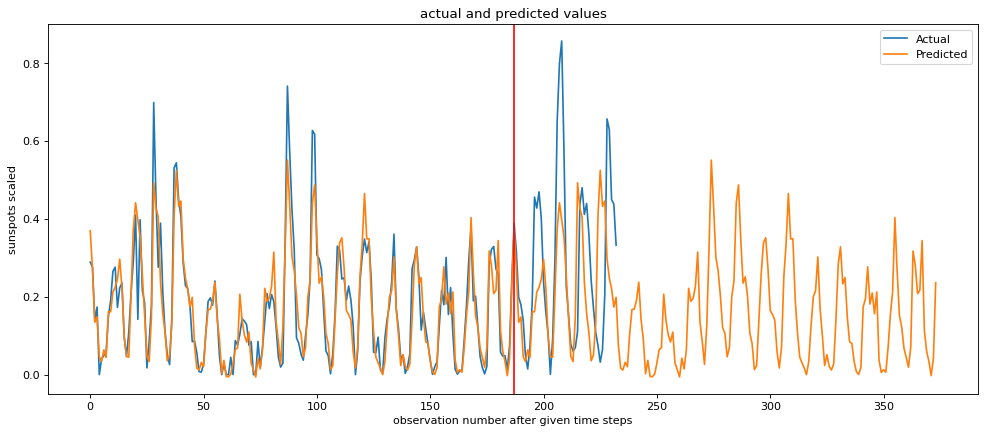

In [61]:
plot_result(trainY,testY,train_predict,test_predict)
#